# Sesión 2 — Clasificación, Sesgo-Varianza y Validación Cruzada

## Objetivos de la sesión

Al terminar esta sesión el estudiante debe ser capaz de:

1. Explicar qué es un problema de **clasificación** y en qué se diferencia de uno de regresión.
2. Construir e interpretar una **matriz de confusión**, y calcular exactitud, precisión, recall y F1.
3. Leer e interpretar una **curva ROC**, una curva **Precision-Recall**, y las curvas de **Lift** y **Ganancia Acumulada**.
4. Explicar el **balance sesgo-varianza** y relacionarlo con *overfitting* y *underfitting*.
5. Discutir el trade-off entre **interpretabilidad y precisión** de un modelo.
6. Aplicar **validación cruzada** (K-Fold y LOOCV) para estimar el desempeño real de un modelo.

## Caso de estudio

A lo largo de la sesión usaremos el dataset **German Credit Data**: 1000 solicitudes
de crédito, cada una descrita por variables como historial crediticio, ahorros,
tipo de vivienda, monto y duración del crédito, etc. El objetivo es predecir si el
cliente es un **buen** o **mal** pagador (`class`: `good` / `bad`). Es exactamente el
tipo de pregunta que motiva esta sesión: *¿el score crediticio y la tenencia de
vivienda de un cliente pueden predecir si pagará su crédito?*


## 1. El problema de clasificación

En la Sesión 1 trabajamos con **regresión**: la variable respuesta $Y$ era
cuantitativa (un número real, como un precio o un ingreso). En muchos problemas
de negocio, sin embargo, lo que queremos predecir es **cualitativo**: una
**categoría** o **etiqueta de clase**. Por ejemplo:

- ¿Este cliente **pagará** o **no pagará** su crédito? (`good` / `bad`)
- ¿Este correo es **spam** o **no spam**?
- ¿Este tumor es **benigno** o **maligno**?
- ¿Este cliente **se irá** (churn) o **se quedará**?

A este tipo de problema se le llama **problema de clasificación**, y a un modelo
que lo resuelve se le llama **clasificador**. Formalmente, buscamos una función

$$\hat{f}: \mathcal{X} \rightarrow \mathcal{C}$$

que asigna a cada observación $x$ (el vector de variables predictoras) una
etiqueta de clase $c \in \mathcal{C} = \{c_1, c_2, \dots, c_K\}$. Cuando
$K=2$ (por ejemplo `good`/`bad`) hablamos de **clasificación binaria**, que es
el caso que trabajaremos hoy.

### ¿Por qué un clasificador y no un regresor?

Podríamos, en principio, codificar `good = 0` y `bad = 1` y ajustar una
regresión lineal sobre esa variable 0/1. El problema es que:

- La regresión lineal puede predecir valores **fuera del rango [0, 1]**
  (por ejemplo, -0.3 o 1.4), que no tienen interpretación como probabilidad
  ni como clase.
- No captura bien la relación **no lineal** típica entre las variables
  predictoras y la probabilidad de pertenecer a una clase (una relación en
  forma de "S", no de línea recta).
- Las métricas de error de regresión (como el RMSE) no son las que nos
  interesan aquí: nos interesa saber **cuántas veces acertamos la clase**,
  y con qué tipo de errores (falsos positivos vs. falsos negativos), que no
  son intercambiables en la mayoría de aplicaciones de negocio.

Por eso usamos modelos diseñados específicamente para clasificación —hoy
veremos **regresión logística** (que sí modela una probabilidad entre 0 y 1
mediante una función sigmoide) y modelos más flexibles como **Random
Forest**.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta de colores consistente para todos los gráficos de la sesión
COLOR = {
    "blue": "#2a78d6",     # modelo 1 (regresión logística)
    "orange": "#eb6834",   # modelo 2 (random forest)
    "aqua": "#1baf7a",     # modelo 3 (ejercicios)
    "gray": "#898781",     # líneas de referencia / baseline
    "grid": "#e1e0d9",     # grillas
}
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = COLOR["grid"]
plt.rcParams["axes.edgecolor"] = COLOR["gray"]


## 2. Cargando los datos: German Credit Data

Usamos `fetch_openml` de scikit-learn, que descarga (y cachea localmente) el
dataset directamente desde OpenML.


In [2]:
d = fetch_openml("credit-g", version=1, as_frame=True, parser="auto")
df = d.frame
print("Filas, columnas:", df.shape)
df.head()


Filas, columnas: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nul

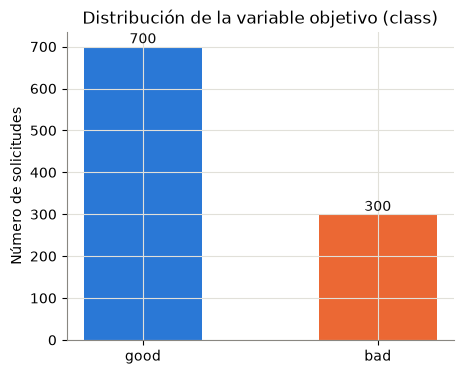

class
good    0.7
bad     0.3
Name: count, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["class"].value_counts()
ax.bar(counts.index, counts.values, color=[COLOR["blue"], COLOR["orange"]], width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, str(v), ha="center", color="#0b0b0b")
ax.set_title("Distribución de la variable objetivo (class)")
ax.set_ylabel("Número de solicitudes")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(counts / counts.sum())


Tenemos **1000 solicitudes**: 700 `good` (70%) y 300 `bad` (30%). Es un
dataset **moderadamente desbalanceado** — algo muy común en riesgo crediticio,
detección de fraude, churn, etc. Este desbalance es justamente la razón por la
que más adelante vamos a preferir la curva **Precision-Recall** sobre la
exactitud simple para evaluar el modelo.


## 3. Preparación de datos: codificación de variables categóricas

La mayoría de los modelos de scikit-learn requieren variables **numéricas**.
El dataset tiene varias columnas categóricas (`checking_status`,
`credit_history`, `purpose`, etc.). Las convertimos a variables *dummy*
(one-hot encoding) con `pd.get_dummies`.

También definimos la variable objetivo: `y = 1` si el crédito es **malo**
(`bad`) y `y = 0` si es **bueno** (`good`). Elegimos `bad` como la "clase
positiva" porque es la clase de interés para el banco (el riesgo que se
quiere detectar) y es, además, la clase minoritaria — el caso típico en
problemas de detección de riesgo.


In [5]:
y = (df["class"] == "bad").astype(int)
X = pd.get_dummies(df.drop(columns=["class"]), drop_first=True)
print("X:", X.shape, " y positivos (bad):", y.sum(), f"({y.mean():.1%})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


X: (1000, 48)  y positivos (bad): 300 (30.0%)
Train: (750, 48)  Test: (250, 48)


Nota: usamos `stratify=y` para que la proporción de `bad`/`good` se
mantenga aproximadamente igual en train y test — algo especialmente
importante cuando las clases están desbalanceadas.


## 4. Entrenando dos modelos: uno simple, uno más flexible

Vamos a entrenar dos clasificadores con la misma información y comparar su
comportamiento durante toda la sesión:

- **Regresión logística** (dentro de un `Pipeline` con estandarización de
  variables): un modelo lineal, simple e interpretable. Alto sesgo, baja
  varianza.
- **Random Forest**: un ensamble de árboles de decisión, mucho más flexible.
  Menor sesgo, pero mayor varianza (más propenso a sobreajustar si no se
  controla su complejidad).


In [6]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

print("Modelos entrenados:", logreg.named_steps["clf"].__class__.__name__, "y", rf.__class__.__name__)


Modelos entrenados: LogisticRegression y RandomForestClassifier


## 5. Métricas de desempeño para clasificación

### Matriz de confusión

La **matriz de confusión** cruza la clase real con la clase predicha. Para
clasificación binaria, con la clase positiva = `bad` (1):

|                     | Predicho: bueno (0) | Predicho: malo (1) |
|---------------------|:---:|:---:|
| **Real: bueno (0)** | TN (Verdadero Negativo) | FP (Falso Positivo) |
| **Real: malo (1)**  | FN (Falso Negativo) | TP (Verdadero Positivo) |

- **TP** (True Positive): predijimos `bad` y sí era `bad`.
- **TN** (True Negative): predijimos `good` y sí era `good`.
- **FP** (False Positive): predijimos `bad` pero en realidad era `good` — un
  "error tipo I" (rechazamos un buen cliente).
- **FN** (False Negative): predijimos `good` pero en realidad era `bad` — un
  "error tipo II" (aprobamos un mal cliente). En riesgo de crédito, este
  suele ser el error más costoso.


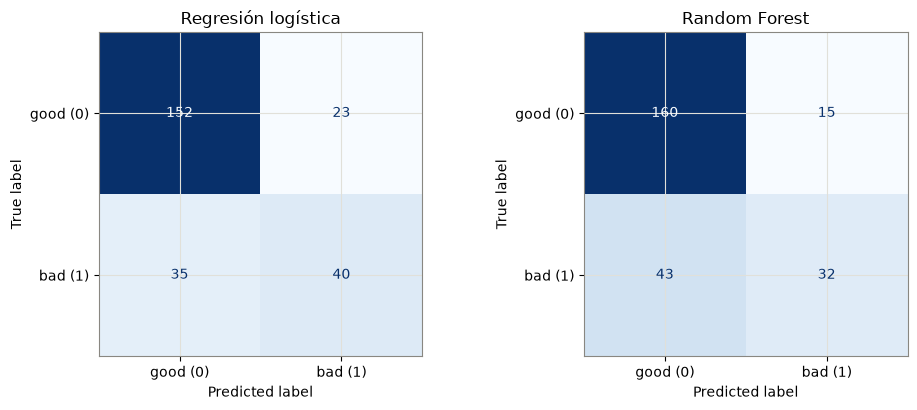

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, model, name in zip(axes, [logreg, rf], ["Regresión logística", "Random Forest"]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, display_labels=["good (0)", "bad (1)"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


### Exactitud, precisión, recall y F-score

A partir de TP, FP, FN, TN se derivan las métricas más usadas:

$$\text{Exactitud (Accuracy)} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precisión} = \frac{TP}{TP + FP} \qquad \text{(de lo que predije como positivo, ¿cuánto acerté?)}$$

$$\text{Recall (Sensibilidad)} = \frac{TP}{TP + FN} \qquad \text{(de todos los positivos reales, ¿cuántos detecté?)}$$

$$F_1 = 2 \cdot \frac{\text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}} \qquad \text{(media armónica de precisión y recall)}$$

Con clases desbalanceadas, la **exactitud puede ser engañosa**: un modelo que
siempre predice `good` acertaría el 70% de las veces sin haber aprendido
nada útil sobre el riesgo. Por eso miramos precisión, recall y F1 en
conjunto — normalmente enfocados en la clase positiva (`bad`).


In [8]:
def resumen_metricas(model, X_test, y_test, nombre):
    y_pred = model.predict(X_test)
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision (bad)": precision_score(y_test, y_pred),
        "recall (bad)": recall_score(y_test, y_pred),
        "f1 (bad)": f1_score(y_test, y_pred),
    }

tabla = pd.DataFrame([
    resumen_metricas(logreg, X_test, y_test, "Regresión logística"),
    resumen_metricas(rf, X_test, y_test, "Random Forest"),
]).set_index("modelo").round(3)
tabla


,accuracy,precision (bad),recall (bad),f1 (bad)
modelo,,,,
Regresión logística,0.768,0.635,0.533,0.580
Random Forest,0.768,0.681,0.427,0.525


Observa que ambos modelos tienen accuracy relativamente alta (cercana al
70-75%, que ya era la proporción de `good`), pero el **recall de la clase
`bad`** — la que de verdad nos importa detectar — es mucho más bajo. Este es
exactamente el efecto del desbalance de clases sobre la accuracy.


### Curva ROC y AUC

Hasta ahora evaluamos el modelo con un umbral fijo de 0.5 sobre la
probabilidad predicha. La curva **ROC** (Receiver Operating Characteristic)
muestra el desempeño del modelo **para todos los posibles umbrales** a la vez,
graficando:

- Eje X: **FPR** (False Positive Rate) $= \frac{FP}{FP+TN}$ — tasa de falsos positivos.
- Eje Y: **TPR** (True Positive Rate) $=$ Recall $= \frac{TP}{TP+FN}$.

Un clasificador aleatorio traza la diagonal (AUC = 0.5). Mientras más se
acerque la curva a la esquina superior izquierda, mejor. El **AUC** (área
bajo la curva) resume esto en un solo número: la probabilidad de que el
modelo asigne una probabilidad más alta a un caso positivo elegido al azar
que a uno negativo elegido al azar.


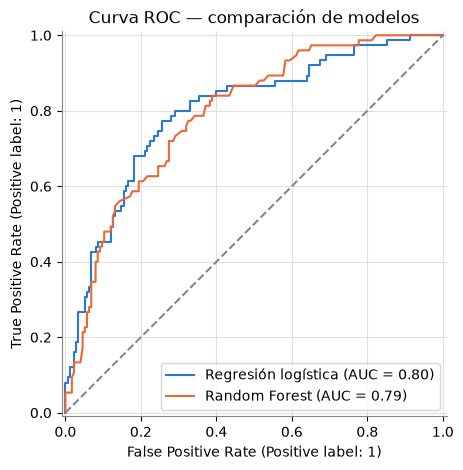

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_estimator(logreg, X_test, y_test, name="Regresión logística", curve_kwargs={"color": COLOR["blue"]}, ax=ax)
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest", curve_kwargs={"color": COLOR["orange"]}, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color=COLOR["gray"], label="Aleatorio (AUC=0.5)")
ax.set_title("Curva ROC — comparación de modelos")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


### Curva Precision-Recall

Cuando las clases están **desbalanceadas** (como aquí: 70/30), la curva ROC
puede ser demasiado optimista, porque el FPR se calcula sobre la clase
negativa (mayoritaria), que es "fácil" de mantener baja. La curva
**Precision-Recall** (Precisión vs. Recall, ambas calculadas sobre la clase
positiva) es más informativa en estos casos, porque no involucra los
verdaderos negativos en absoluto.

La línea base de un clasificador aleatorio en esta curva no es la diagonal,
sino una línea horizontal en `precisión = proporción de positivos` (aquí,
0.30).


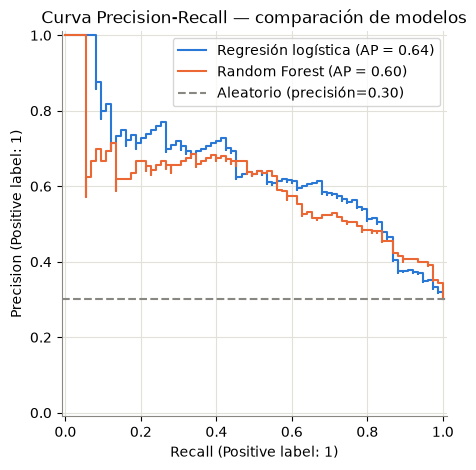

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
PrecisionRecallDisplay.from_estimator(logreg, X_test, y_test, name="Regresión logística", curve_kwargs={"color": COLOR["blue"]}, ax=ax)
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, name="Random Forest", curve_kwargs={"color": COLOR["orange"]}, ax=ax)
baseline = y_test.mean()
ax.axhline(baseline, linestyle="--", color=COLOR["gray"], label=f"Aleatorio (precisión={baseline:.2f})")
ax.set_title("Curva Precision-Recall — comparación de modelos")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


### Curvas de Lift y Ganancia Acumulada (Cumulative Gain)

Estas curvas responden una pregunta muy práctica para negocio: *si ordeno a
todos los clientes de mayor a menor probabilidad predicha, y solo puedo
"tratar" (revisar manualmente, contactar, etc.) al x% con mayor probabilidad,
¿cuántos de los casos positivos reales estoy capturando, y qué tan mejor es
eso comparado con elegir al azar?*

- **Ganancia Acumulada (Cumulative Gain)**: eje X = % de la población
  contactada (ordenada por probabilidad predicha, de mayor a menor), eje Y =
  % acumulado de positivos reales capturados. La línea base aleatoria es la
  diagonal.
- **Lift**: es la ganancia acumulada dividida por la proporción de datos
  usada, es decir, cuántas veces mejor que el azar es el modelo en ese punto
  de corte. La línea base aleatoria es una horizontal en 1.

No vienen implementadas directamente en scikit-learn, pero son sencillas de
calcular manualmente:


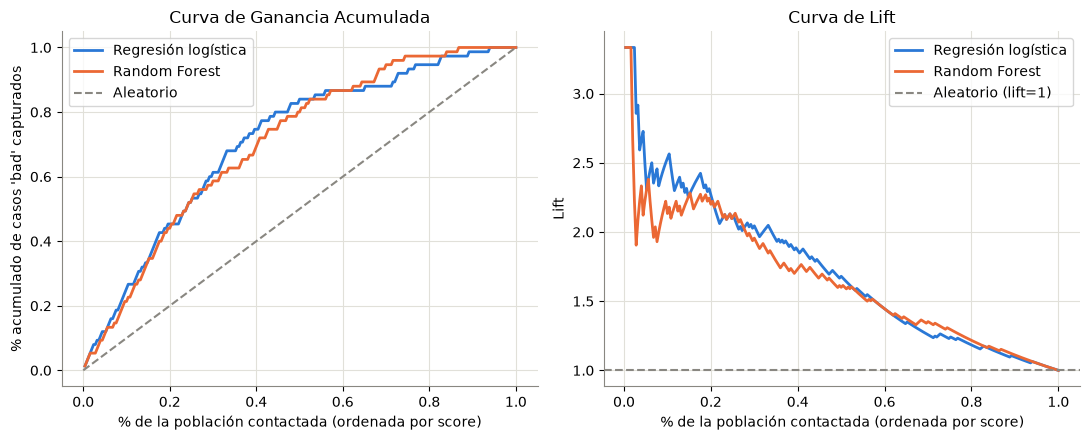

In [11]:
def curva_ganancia_lift(y_true, y_score):
    orden = np.argsort(-y_score)
    y_ordenado = np.asarray(y_true)[orden]
    n = len(y_ordenado)
    positivos_totales = y_ordenado.sum()

    pct_poblacion = np.arange(1, n + 1) / n
    ganancia_acumulada = np.cumsum(y_ordenado) / positivos_totales
    lift = ganancia_acumulada / pct_poblacion
    return pct_poblacion, ganancia_acumulada, lift


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for model, name, color in [(logreg, "Regresión logística", COLOR["blue"]), (rf, "Random Forest", COLOR["orange"])]:
    proba = model.predict_proba(X_test)[:, 1]
    pct, ganancia, lift = curva_ganancia_lift(y_test, proba)
    axes[0].plot(pct, ganancia, label=name, color=color, linewidth=2)
    axes[1].plot(pct, lift, label=name, color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], linestyle="--", color=COLOR["gray"], label="Aleatorio")
axes[0].set_xlabel("% de la población contactada (ordenada por score)")
axes[0].set_ylabel("% acumulado de casos 'bad' capturados")
axes[0].set_title("Curva de Ganancia Acumulada")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].axhline(1.0, linestyle="--", color=COLOR["gray"], label="Aleatorio (lift=1)")
axes[1].set_xlabel("% de la población contactada (ordenada por score)")
axes[1].set_ylabel("Lift")
axes[1].set_title("Curva de Lift")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


**Lectura práctica**: si el banco solo tiene capacidad para revisar
manualmente al 20% de las solicitudes con mayor score de riesgo, la curva de
ganancia acumulada nos dice directamente qué porcentaje de los créditos
realmente malos estaría capturando en ese 20% — y la curva de lift nos dice
cuántas veces mejor es eso que revisar un 20% al azar.


## 6. Sesgo vs. Varianza

Todo modelo comete error por dos razones distintas (más el ruido irreducible
de los datos):

- **Sesgo (bias)**: el error que viene de las **suposiciones simplificadoras**
  del modelo. Un modelo con alto sesgo tiende a **ignorar información** real
  presente en los datos y a aprender relaciones incorrectas o demasiado
  simples (p. ej., asumir una frontera de decisión lineal cuando la real es
  curva). Es un problema estructural del modelo, no de los datos de
  entrenamiento en particular.
- **Varianza**: qué tanto **cambiaría el modelo ajustado** si lo
  entrenáramos con una muestra de entrenamiento distinta. Un modelo con alta
  varianza es muy **sensible a pequeños cambios** en los datos de
  entrenamiento — puede ajustar el ruido específico de esa muestra en vez del
  patrón general.

**Regla general**: entre más flexible (compleja) es la familia de modelos,
menor es su sesgo (puede representar relaciones más ricas) pero mayor es su
varianza (tiene más "grados de libertad" para sobreajustarse a la muestra
particular de entrenamiento). El error total esperado sobre datos nuevos se
puede descomponer, de forma simplificada, como:

$$\text{Error esperado} \approx \text{Sesgo}^2 + \text{Varianza} + \text{Error irreducible}$$

Esto genera la clásica curva en forma de "U" del error de prueba en función
de la complejidad del modelo, con un punto óptimo en el medio:


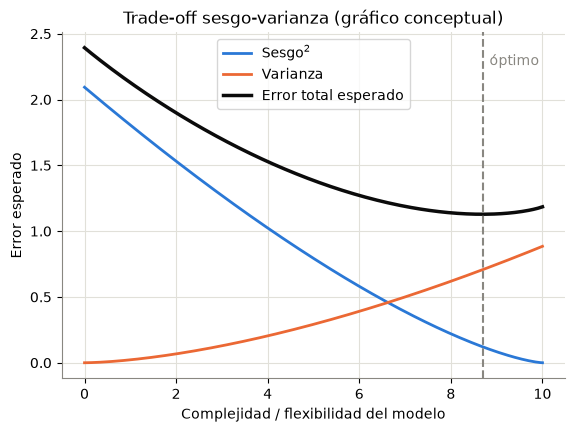

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
complejidad = np.linspace(0, 10, 200)
sesgo2 = (10 - complejidad) ** 1.4 / 12
varianza = (complejidad ** 1.6) / 45
error_total = sesgo2 + varianza + 0.3

ax.plot(complejidad, sesgo2, color=COLOR["blue"], linewidth=2, label="Sesgo$^2$")
ax.plot(complejidad, varianza, color=COLOR["orange"], linewidth=2, label="Varianza")
ax.plot(complejidad, error_total, color="#0b0b0b", linewidth=2.5, label="Error total esperado")

optimo = complejidad[np.argmin(error_total)]
ax.axvline(optimo, linestyle="--", color=COLOR["gray"])
ax.text(optimo + 0.15, ax.get_ylim()[1] * 0.9, "óptimo", color=COLOR["gray"])

ax.set_xlabel("Complejidad / flexibilidad del modelo")
ax.set_ylabel("Error esperado")
ax.set_title("Trade-off sesgo-varianza (gráfico conceptual)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.show()


En nuestro caso de estudio, la **regresión logística** (modelo lineal)
está más hacia la izquierda de este eje: menos flexible, más sesgo, menos
varianza. El **Random Forest** sin restricciones está más hacia la derecha:
muy flexible, menos sesgo, pero más riesgo de alta varianza / overfitting.


## 7. Overfitting y Underfitting

- **Overfitting (sobreajuste)**: el modelo se ajusta muy bien a los datos de
  entrenamiento (error de entrenamiento bajo) pero **no generaliza** a datos
  nuevos (error de prueba alto). Causas típicas: modelo demasiado complejo
  para la cantidad de datos disponible, datos ruidosos, muy pocos datos de
  entrenamiento. Soluciones típicas: simplificar el modelo, conseguir más
  datos, reducir el ruido/las variables irrelevantes, o aplicar
  **regularización**.
- **Underfitting (subajuste)**: el modelo ni siquiera se ajusta bien a los
  datos de entrenamiento (error de entrenamiento ya alto). Causas típicas:
  modelo demasiado simple, features poco informativas. Soluciones típicas:
  usar un modelo más flexible, construir mejores features, relajar
  restricciones de regularización.

Podemos ilustrar esto directamente sobre nuestros datos, variando la
**profundidad máxima** de un árbol de decisión (un solo parámetro que
controla su complejidad) y observando el error de entrenamiento vs. el error
de prueba:


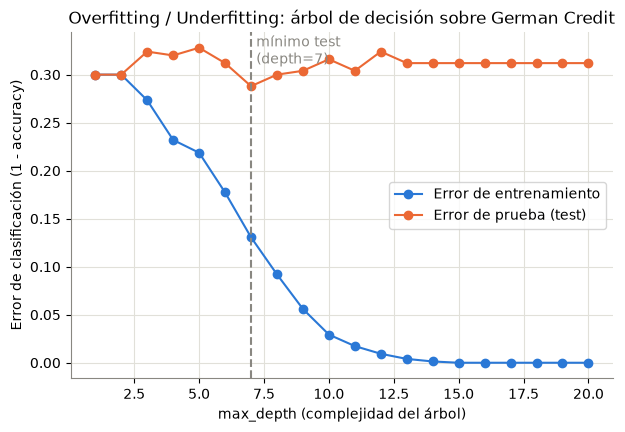

In [13]:
profundidades = range(1, 21)
error_train, error_test = [], []

for prof in profundidades:
    arbol = DecisionTreeClassifier(max_depth=prof, random_state=RANDOM_STATE)
    arbol.fit(X_train, y_train)
    error_train.append(1 - accuracy_score(y_train, arbol.predict(X_train)))
    error_test.append(1 - accuracy_score(y_test, arbol.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(profundidades), error_train, marker="o", color=COLOR["blue"], label="Error de entrenamiento")
ax.plot(list(profundidades), error_test, marker="o", color=COLOR["orange"], label="Error de prueba (test)")

mejor_prof = list(profundidades)[int(np.argmin(error_test))]
ax.axvline(mejor_prof, linestyle="--", color=COLOR["gray"])
ax.text(mejor_prof + 0.2, max(error_test) * 0.95, f"mínimo test\n(depth={mejor_prof})", color=COLOR["gray"])

ax.set_xlabel("max_depth (complejidad del árbol)")
ax.set_ylabel("Error de clasificación (1 - accuracy)")
ax.set_title("Overfitting / Underfitting: árbol de decisión sobre German Credit")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.show()


Se observa el patrón típico: con `max_depth` muy bajo, tanto el error de
entrenamiento como el de prueba son altos (**underfitting** — el árbol es
demasiado simple para capturar el patrón). A medida que aumentamos la
profundidad, el error de entrenamiento sigue bajando (incluso hasta casi 0),
pero el error de prueba deja de mejorar y eventualmente empieza a subir
(**overfitting** — el árbol empieza a memorizar particularidades de la
muestra de entrenamiento que no generalizan).


## 8. Interpretabilidad vs. Precisión

Existe con frecuencia un **trade-off** entre qué tan fácil es *explicar* un
modelo y qué tan *preciso* puede llegar a ser:

- Modelos **simples e interpretables** (regresión lineal/logística, árboles
  poco profundos): es fácil explicar exactamente cómo cada variable afecta la
  predicción (un coeficiente, una regla). Muy valorado en contextos regulados
  (riesgo crediticio, salud, sector público), donde hay que **justificar**
  una decisión ante un cliente o un regulador. A cambio, suelen tener mayor
  sesgo (menor precisión potencial).
- Modelos **complejos y de caja negra** (random forest, gradient boosting,
  redes neuronales): suelen lograr mayor precisión al capturar relaciones no
  lineales e interacciones entre variables, pero es mucho más difícil
  explicar *por qué* el modelo tomó una decisión particular para un caso
  específico.

Podemos ilustrar esto comparando los **coeficientes** de la regresión
logística (fácilmente interpretables) contra la **importancia de variables**
del Random Forest:


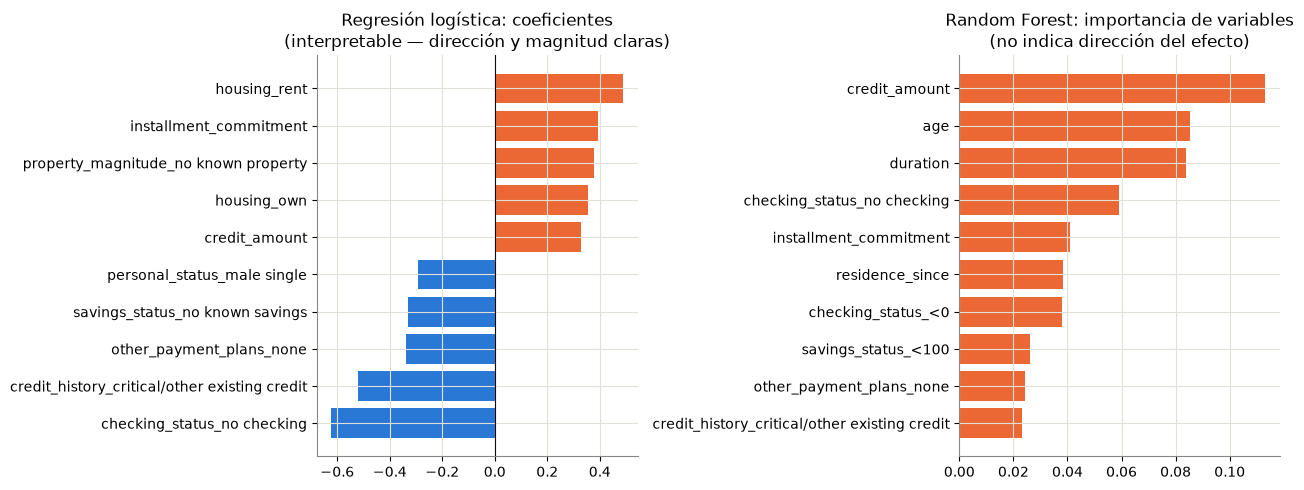

In [14]:
coefs = pd.Series(logreg.named_steps["clf"].coef_[0], index=X.columns).sort_values()
top_coefs = pd.concat([coefs.head(5), coefs.tail(5)])

importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_coef = [COLOR["blue"] if v < 0 else COLOR["orange"] for v in top_coefs.values]
axes[0].barh(top_coefs.index, top_coefs.values, color=colors_coef)
axes[0].set_title("Regresión logística: coeficientes\n(interpretable — dirección y magnitud claras)")
axes[0].axvline(0, color="#0b0b0b", linewidth=0.8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(importancias.index[::-1], importancias.values[::-1], color=COLOR["orange"])
axes[1].set_title("Random Forest: importancia de variables\n(no indica dirección del efecto)")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


En la regresión logística podemos decir, por ejemplo, "un
`checking_status` con más fondos disponibles **reduce** la probabilidad de
`bad` en tal magnitud" — una explicación directa y auditable. En el Random
Forest solo sabemos **qué tan importante** fue cada variable para reducir la
impureza de los árboles, pero no la dirección ni la magnitud exacta del
efecto — de ahí que se necesiten técnicas adicionales (SHAP, LIME, etc., que
verás más adelante en el curso) para interpretar modelos de caja negra.


## 9. Validación cruzada

### ¿Por qué no basta con el error de entrenamiento?

El error medido sobre los mismos datos con los que se entrenó el modelo
(**error de entrenamiento**) **subestima sistemáticamente** el error real
sobre datos nuevos, porque el modelo tuvo la oportunidad de "memorizar"
particularidades de esa muestra. Necesitamos estimar el error sobre datos que
el modelo **no vio** durante el entrenamiento — eso es exactamente lo que
hace un conjunto de prueba (test), pero un solo split train/test depende de
*qué* observaciones cayeron en cada partición (tiene su propia varianza). La
**validación cruzada** promedia esta estimación sobre varias particiones
distintas, dando una medida más estable y confiable.

### Leave-One-Out Cross-Validation (LOOCV)

Con $n$ observaciones, se entrena el modelo $n$ veces: en cada iteración se
deja **una sola observación** fuera como prueba, y se entrena con las $n-1$
restantes. El error final es el promedio de los $n$ errores individuales.

- **Ventaja**: usa casi todos los datos para entrenar en cada iteración →
  estimación del error con **muy poco sesgo**.
- **Desventaja**: computacionalmente **muy costoso** (hay que entrenar $n$
  modelos) y, además, las $n$ estimaciones están muy correlacionadas entre sí
  (los conjuntos de entrenamiento se solapan casi por completo), por lo que
  la estimación final puede tener **alta varianza**.

### K-Fold Cross-Validation

Se divide aleatoriamente el dataset en $k$ particiones ("folds") de tamaño
aproximadamente igual. En cada una de las $k$ iteraciones, se usa un fold
distinto como prueba y los $k-1$ restantes como entrenamiento. El resultado
final es el promedio (y la desviación estándar, que nos da una idea de la
variabilidad) de las $k$ métricas obtenidas.

- Es un **balance costo/varianza**: computacionalmente mucho más barato que
  LOOCV (solo $k$ modelos, no $n$), y con menor varianza en la estimación
  final que LOOCV, a cambio de un poco más de sesgo.
- LOOCV es, de hecho, el caso particular $k = n$.
- En la práctica se suele usar $k = 5$ o $k = 10$: es el balance que mejor
  funciona empíricamente entre sesgo y varianza de la estimación, con un
  costo computacional razonable.


In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_kfold = cross_val_score(logreg, X, y, cv=kf, scoring="f1")

print("F1 por fold (K=5):", np.round(scores_kfold, 3))
print(f"F1 promedio: {scores_kfold.mean():.3f}  (desviación estándar: {scores_kfold.std():.3f})")

f1_single_split = f1_score(y_test, logreg.predict(X_test))
print(f"\nF1 de una sola partición train/test: {f1_single_split:.3f}")


F1 por fold (K=5): [0.642 0.515 0.553 0.505 0.514]
F1 promedio: 0.546  (desviación estándar: 0.051)

F1 de una sola partición train/test: 0.580


Nota cómo el F1 de una sola partición train/test puede diferir bastante
del promedio de K-Fold — y ese promedio viene acompañado de una desviación
estándar que nos dice **qué tan estable** es esa estimación. Ahora veamos
LOOCV sobre el mismo modelo (con `n_jobs=-1` para paralelizar, ya que implica
entrenar 1000 modelos):


In [16]:
loo_scores = cross_val_score(logreg, X, y, cv=LeaveOneOut(), scoring="accuracy", n_jobs=-1)
print(f"LOOCV (n={len(loo_scores)} folds) — accuracy promedio: {loo_scores.mean():.3f}")

kfold_acc = cross_val_score(logreg, X, y, cv=kf, scoring="accuracy")
print(f"K-Fold (k=5) — accuracy promedio: {kfold_acc.mean():.3f}  (std: {kfold_acc.std():.3f})")


LOOCV (n=1000 folds) — accuracy promedio: 0.754
K-Fold (k=5) — accuracy promedio: 0.753  (std: 0.029)


En este caso, LOOCV y K-Fold dan estimaciones muy similares del error
promedio (poco sesgo en ambos), pero K-Fold es órdenes de magnitud más barato
computacionalmente y además nos entrega directamente una desviación estándar
entre folds (con LOOCV, con `n=1000` folds de tamaño 1, esa desviación es
mucho menos informativa fold a fold). Por eso K-Fold con k=5 o 10 es, en la
práctica, la opción por defecto casi siempre.


## Ejercicios de práctica

Resuelve cada ejercicio en la celda marcada con `# TODO`. Debajo de cada uno
encontrarás una celda de "Solución" — intenta resolverlo por tu cuenta antes
de mirarla.


### Ejercicio 1 — Comparar un tercer modelo con curvas ROC

Entrena un tercer modelo (por ejemplo, un `DecisionTreeClassifier` con
`max_depth=5` o un `SVC(probability=True)`) sobre `X_train`/`y_train`.
Grafica su curva ROC junto a las de `logreg` y `rf` (puedes reutilizar
`RocCurveDisplay.from_estimator` pasando el mismo `ax`). Compara los AUC de
los tres modelos: ¿cuál es mayor? ¿Coincide con el modelo que consideras
"mejor" en la práctica, considerando también la interpretabilidad?


In [17]:
# TODO: 1) entrena un tercer modelo (ej. DecisionTreeClassifier(max_depth=5) o SVC(probability=True))
# TODO: 2) usa RocCurveDisplay.from_estimator para graficar su curva ROC junto a las de logreg y rf
# TODO: 3) compara los AUC de los tres modelos y concluye cuál preferirías y por qué


#### Solución 1

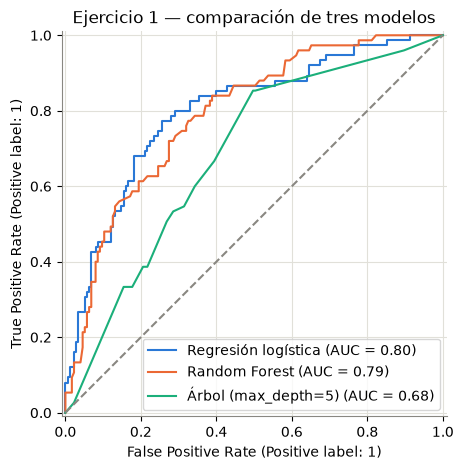

In [18]:
arbol_ej1 = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
arbol_ej1.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_estimator(logreg, X_test, y_test, name="Regresión logística", curve_kwargs={"color": COLOR["blue"]}, ax=ax)
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest", curve_kwargs={"color": COLOR["orange"]}, ax=ax)
RocCurveDisplay.from_estimator(arbol_ej1, X_test, y_test, name="Árbol (max_depth=5)", curve_kwargs={"color": COLOR["aqua"]}, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color=COLOR["gray"], label="Aleatorio")
ax.set_title("Ejercicio 1 — comparación de tres modelos")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

# En general, Random Forest suele tener el AUC más alto (modelo más flexible),
# seguido del árbol individual, y la regresión logística suele quedar algo más
# atrás en AUC puro — pero sigue siendo la opción más fácil de explicar/auditar.


### Ejercicio 2 — Ajustar el umbral de decisión

Por defecto, un clasificador predice la clase positiva cuando la probabilidad
estimada supera 0.5. Usando las probabilidades de `logreg` sobre `X_test`
(`logreg.predict_proba(X_test)[:, 1]`), calcula precisión y recall (de la
clase `bad`) para al menos 3 umbrales distintos (por ejemplo 0.3, 0.5 y 0.7).
¿Qué umbral usarías si el banco quiere **minimizar el riesgo** de aprobar
créditos malos, es decir, maximizar el recall de `bad`, aun a costa de
precisión?


In [19]:
# TODO: 1) obtén las probabilidades predichas por logreg sobre X_test para la clase 'bad'
# TODO: 2) para umbrales = [0.2, 0.3, 0.5, 0.7, 0.8], calcula y_pred = (proba >= umbral)
# TODO: 3) calcula precision_score y recall_score para cada umbral y arma una tabla
# TODO: 4) concluye qué umbral recomendarías si el banco prioriza recall sobre precisión


#### Solución 2

In [20]:
proba_test = logreg.predict_proba(X_test)[:, 1]
umbrales = [0.2, 0.3, 0.5, 0.7, 0.8]

filas = []
for u in umbrales:
    y_pred_u = (proba_test >= u).astype(int)
    filas.append({
        "umbral": u,
        "precision (bad)": precision_score(y_test, y_pred_u, zero_division=0),
        "recall (bad)": recall_score(y_test, y_pred_u, zero_division=0),
        "f1 (bad)": f1_score(y_test, y_pred_u, zero_division=0),
    })

tabla_umbrales = pd.DataFrame(filas).set_index("umbral").round(3)
tabla_umbrales

# A umbrales más bajos (ej. 0.2-0.3), el modelo clasifica como 'bad' a más clientes,
# lo que aumenta el recall (detecta más créditos malos reales) pero baja la precisión
# (más falsos positivos: buenos clientes rechazados). Si el banco quiere minimizar el
# riesgo de aprobar créditos malos, conviene un umbral bajo, aceptando rechazar más
# buenos clientes a cambio de perder menos créditos malos.


,precision (bad),recall (bad),f1 (bad)
umbral,,,
0.2,0.474,0.840,0.606
0.3,0.547,0.773,0.641
0.5,0.635,0.533,0.580
0.7,0.690,0.267,0.385
0.8,0.733,0.147,0.244


### Ejercicio 3 — Comparar distintos valores de k en K-Fold

Repite la validación cruzada K-Fold sobre `logreg` con distintos valores de
`k` (por ejemplo, 3, 5 y 10), usando `scoring="f1"`. Para cada `k`, calcula la
media y la desviación estándar del F1 entre folds. ¿Qué le pasa a la
desviación estándar a medida que `k` aumenta? ¿Por qué crees que ocurre eso?


In [21]:
# TODO: 1) para k en [3, 5, 10], crea un KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
# TODO: 2) calcula cross_val_score(logreg, X, y, cv=kf, scoring="f1") para cada k
# TODO: 3) reporta media y desviación estándar del F1 para cada k en una tabla
# TODO: 4) concluye qué pasa con la varianza de la estimación a medida que k crece


#### Solución 3

In [22]:
filas_k = []
for k in [3, 5, 10]:
    kf_k = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores_k = cross_val_score(logreg, X, y, cv=kf_k, scoring="f1")
    filas_k.append({"k": k, "f1_medio": scores_k.mean(), "f1_std": scores_k.std()})

tabla_k = pd.DataFrame(filas_k).set_index("k").round(4)
tabla_k

# A medida que k aumenta, cada fold de entrenamiento se parece más al dataset completo
# (usamos más datos para entrenar en cada iteración), por lo que el sesgo de la estimación
# disminuye. Sin embargo, con k grande los folds de entrenamiento se solapan más entre sí,
# lo que puede aumentar la varianza de la estimación entre folds (menos "independencia"
# entre iteraciones) y el costo computacional también crece. Con k=10 se suele lograr un
# buen balance costo/sesgo/varianza para datasets de este tamaño.


,f1_medio,f1_std
k,,
3,0.5285,0.0470
5,0.5458,0.0510
10,0.5284,0.1096


## Resumen de conceptos clave

- Un problema de **clasificación** busca asignar una etiqueta de clase (no un
  número continuo); usamos modelos como regresión logística o Random Forest,
  no regresión lineal.
- La **matriz de confusión** (TP, FP, FN, TN) es la base de todas las
  métricas de clasificación: exactitud, precisión, recall y F1.
- La **exactitud puede engañar** en datasets desbalanceados — por eso
  miramos precisión/recall/F1 de la clase de interés, la curva **ROC**
  (y su AUC), y sobre todo la curva **Precision-Recall** cuando hay
  desbalance.
- Las curvas de **Lift** y **Ganancia Acumulada** traducen el desempeño del
  modelo a una pregunta de negocio directa: *"¿cuánto mejor que el azar soy
  si solo puedo actuar sobre el x% con mayor score?"*
- El **sesgo** es el error por simplificar de más; la **varianza** es la
  sensibilidad del modelo a la muestra de entrenamiento particular. A mayor
  flexibilidad del modelo, generalmente menor sesgo pero mayor varianza.
- **Underfitting**: el modelo falla incluso en entrenamiento (modelo muy
  simple). **Overfitting**: el modelo memoriza el entrenamiento pero no
  generaliza (modelo muy complejo, pocos datos, mucho ruido).
- Existe un **trade-off entre interpretabilidad y precisión**: modelos
  simples se explican fácil pero pueden tener más sesgo; modelos complejos
  suelen ser más precisos pero más difíciles de auditar.
- El error de entrenamiento **subestima** el error real. La **validación
  cruzada** (K-Fold, típicamente k=5 o 10; o LOOCV, el caso extremo k=n) da
  una estimación más confiable y estable del desempeño de un modelo sobre
  datos nuevos.

En la próxima sesión profundizaremos en árboles de decisión, ensambles
(bagging, boosting) y técnicas específicas para datos desbalanceados.
